# Compare Human Evaluators Against Model Labels

In [1]:
import pandas as pd
import os
from functools import reduce
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, classification_report
from collections import Counter

## Load Data

In [2]:
gpt3_model_df = (pd.read_excel('./gpt_labelled_notes/gpt3_labelled_notes.xlsx')).rename(columns={'needs':'model'})
gpt4_model_df = (pd.read_excel('./gpt_labelled_notes/gpt4_labelled_notes.xlsx')).rename(columns={'needs':'model'})

In [3]:
gpt3_dfs = []
gpt4_dfs = []
for folder in os.listdir('./dataPreparationForEvaluation/unlabelled_notes_experiment/'):
    if '.' not in folder:
        for file in os.listdir(f'./dataPreparationForEvaluation/unlabelled_notes_experiment/{folder}'):
            if '.xlsx' in file:
                if 'gpt3' in file:
                    gpt3_dfs.append(pd.read_excel(f'./dataPreparationForEvaluation/unlabelled_notes_experiment/{folder}/{file}'))
                elif 'gpt4' in file:
                    gpt4_dfs.append(pd.read_excel(f'./dataPreparationForEvaluation/unlabelled_notes_experiment/{folder}/{file}'))
                else:
                    print('Not sure if its gpt3 or gpt4...')

/Users/isabel/anaconda3/envs/syntheticNotes/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/isabel/anaconda3/envs/syntheticNotes/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [4]:
def merge_dfs(dfs):
    temp_dfs = []
    for i, df in enumerate(dfs):
        copy_df = df.copy()
        copy_df = copy_df[['report', 'needs']]
        copy_df.rename(columns={'needs': f'rater{i+1}'}, inplace=True)
        temp_dfs.append(copy_df)

    merged = reduce(lambda left, right: pd.merge(left, right, on='report'), temp_dfs)
    return merged

In [5]:
gpt3_raters = merge_dfs(gpt3_dfs)
gpt4_raters = merge_dfs(gpt4_dfs)

In [6]:
print(f'GPT3 Before NaN Removal: {len(gpt3_raters)}')
print(f'GPT4 Before NaN Removal: {len(gpt4_raters)}')

clean_gpt3_raters = gpt3_raters.dropna(subset=['rater1', 'rater2', 'rater3'])
clean_gpt4_raters = gpt4_raters.dropna(subset=['rater1', 'rater2', 'rater3'])

clean_gpt3_raters = gpt3_model_df.merge(clean_gpt3_raters, on='report')
clean_gpt4_raters = gpt4_model_df.merge(clean_gpt4_raters, on='report')

print(f'GPT3 After NaN Removal: {len(clean_gpt3_raters)}')
print(f'GPT4 After NaN Removal: {len(clean_gpt4_raters)}')

GPT3 Before NaN Removal: 598
GPT4 Before NaN Removal: 650
GPT3 After NaN Removal: 597
GPT4 After NaN Removal: 650


In [7]:
def make_count_matrix(merged_clean):
    label_counts = []
    for _, row in merged_clean.iterrows():
        counts = {'met': 0, 'unmet': 0}
        for label in [row['rater1'], row['rater2'], row['rater3']]:
            counts[label] += 1
        label_counts.append([counts['met'], counts['unmet']])

    rating_matrix = np.array(label_counts)
    return rating_matrix

In [8]:
gpt3_cm = make_count_matrix(clean_gpt3_raters)
gpt4_cm = make_count_matrix(clean_gpt4_raters)

## Fleiss' Kappa Scores

In [9]:
# Fleiss Kappa interpretation can be found here: https://onlinelibrary.wiley.com/doi/full/10.1002/qaj.481
kappa_score_gpt3 = fleiss_kappa(gpt3_cm, method='fleiss')
print("Fleiss' Kappa GPT3:", round(kappa_score_gpt3, 3))

kappa_score_gpt4 = fleiss_kappa(gpt4_cm, method='fleiss')
print("Fleiss' Kappa GPT4:", round(kappa_score_gpt4, 3))

Fleiss' Kappa GPT3: 0.151
Fleiss' Kappa GPT4: 0.124


## Get Metrics for Raters

In [10]:
def get_rater_scores(comparison_df, gpt_model):
    for rater in [col for col in comparison_df.columns if col.startswith('rater')]:
        print(f"--- Evaluation for {rater} ---")
        print("Accuracy:", accuracy_score(comparison_df['model'], comparison_df[rater]))
        print("Precision:", precision_score(comparison_df['model'], comparison_df[rater], pos_label = 'unmet'))
        print("Recall:", recall_score(comparison_df['model'], comparison_df[rater], pos_label = 'unmet'))
        print("F1 Score:", f1_score(comparison_df['model'], comparison_df[rater], pos_label = 'unmet'))
        print("Cohen's Kappa:", cohen_kappa_score(comparison_df['model'], comparison_df[rater]))
        print(classification_report(comparison_df['model'], comparison_df[rater]))
        print()

        conf_matrix = confusion_matrix(comparison_df[rater], comparison_df['model'])
        ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['met', 'unmet']).plot()
        plt.xlabel('GPT Labels')
        plt.ylabel('Nurse Labels')
        plt.title(f'Rater {rater.replace('rater', '')} vs {gpt_model}')
        plt.savefig(f"./graphs/{gpt_model.replace('-', '').replace('.', '')}_{rater}.png")
        plt.show()

--- Evaluation for rater1 ---
Accuracy: 0.5644891122278057
Precision: 0.5586206896551724
Recall: 0.5510204081632653
F1 Score: 0.5547945205479452
Cohen's Kappa: 0.12860414982484503
              precision    recall  f1-score   support

         met       0.57      0.58      0.57       303
       unmet       0.56      0.55      0.55       294

    accuracy                           0.56       597
   macro avg       0.56      0.56      0.56       597
weighted avg       0.56      0.56      0.56       597




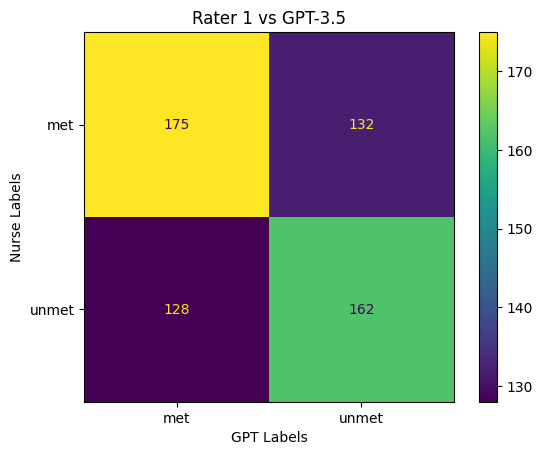

--- Evaluation for rater2 ---
Accuracy: 0.5108877721943048
Precision: 0.5058139534883721
Recall: 0.29591836734693877
F1 Score: 0.37339055793991416
Cohen's Kappa: 0.015485751075870025
              precision    recall  f1-score   support

         met       0.51      0.72      0.60       303
       unmet       0.51      0.30      0.37       294

    accuracy                           0.51       597
   macro avg       0.51      0.51      0.49       597
weighted avg       0.51      0.51      0.49       597




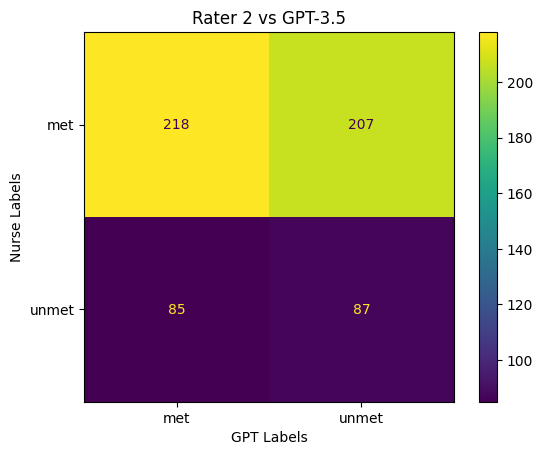

--- Evaluation for rater3 ---
Accuracy: 0.7085427135678392
Precision: 0.6327433628318584
Recall: 0.9727891156462585
F1 Score: 0.7667560321715817
Cohen's Kappa: 0.42156961010323746
              precision    recall  f1-score   support

         met       0.94      0.45      0.61       303
       unmet       0.63      0.97      0.77       294

    accuracy                           0.71       597
   macro avg       0.79      0.71      0.69       597
weighted avg       0.79      0.71      0.69       597




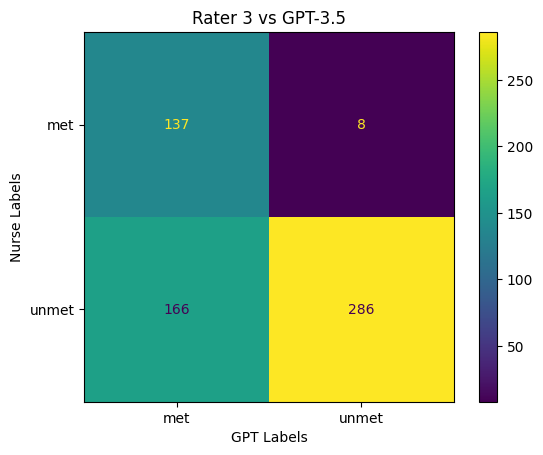

In [11]:
get_rater_scores(clean_gpt3_raters, 'GPT-3.5')

--- Evaluation for rater1 ---
Accuracy: 0.4969230769230769
Precision: 0.47257383966244726
Recall: 0.35668789808917195
F1 Score: 0.40653357531760437
Cohen's Kappa: -0.015460026562962748
              precision    recall  f1-score   support

         met       0.51      0.63      0.56       336
       unmet       0.47      0.36      0.41       314

    accuracy                           0.50       650
   macro avg       0.49      0.49      0.48       650
weighted avg       0.49      0.50      0.49       650




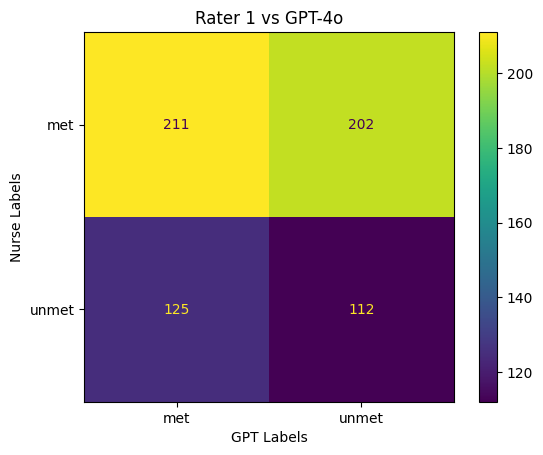

--- Evaluation for rater2 ---
Accuracy: 0.4846153846153846
Precision: 0.4406779661016949
Recall: 0.2484076433121019
F1 Score: 0.31771894093686354
Cohen's Kappa: -0.04690519918843816
              precision    recall  f1-score   support

         met       0.50      0.71      0.59       336
       unmet       0.44      0.25      0.32       314

    accuracy                           0.48       650
   macro avg       0.47      0.48      0.45       650
weighted avg       0.47      0.48      0.46       650




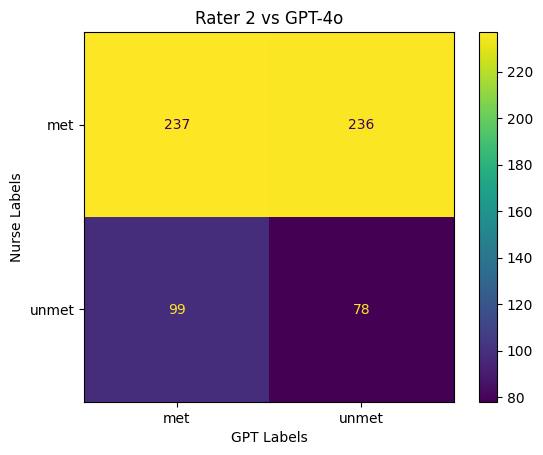

--- Evaluation for rater3 ---
Accuracy: 0.5138461538461538
Precision: 0.4982078853046595
Recall: 0.8853503184713376
F1 Score: 0.6376146788990825
Cohen's Kappa: 0.0507265131068142
              precision    recall  f1-score   support

         met       0.61      0.17      0.26       336
       unmet       0.50      0.89      0.64       314

    accuracy                           0.51       650
   macro avg       0.55      0.53      0.45       650
weighted avg       0.56      0.51      0.44       650




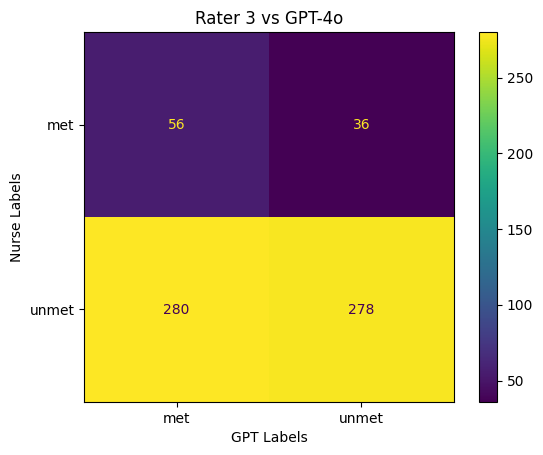

In [12]:
get_rater_scores(clean_gpt4_raters, 'GPT-4o')

## Get Majority Vote Metrics

In [13]:
def majority_votes(comparison_df):
    def majority_vote(row):    
        votes = [row[col] for col in row.index if col.startswith('rater')]
        count = Counter(votes)
        return count.most_common(1)[0][0]

    comparison_df['majority_vote'] = comparison_df[[col for col in comparison_df.columns if col.startswith('rater')]].apply(majority_vote, axis=1)
    return comparison_df

In [14]:
clean_gpt3_raters = majority_votes(clean_gpt3_raters)
clean_gpt4_raters = majority_votes(clean_gpt4_raters)

In [15]:
def get_majority_scores(comparison_df, gpt_model):
    print(f"--- Evaluation for Majority Vote ---")
    print("Accuracy:", accuracy_score(comparison_df['model'], comparison_df['majority_vote']))
    print("Precision:", precision_score(comparison_df['model'], comparison_df['majority_vote'], pos_label = 'unmet'))
    print("Recall:", recall_score(comparison_df['model'], comparison_df['majority_vote'], pos_label = 'unmet'))
    print("F1 Score:", f1_score(comparison_df['model'], comparison_df['majority_vote'], pos_label = 'unmet'))
    print("Cohen's Kappa:", cohen_kappa_score(comparison_df['model'], comparison_df['majority_vote']))
    print(classification_report(comparison_df['model'], comparison_df['majority_vote']))
    print()

    conf_matrix = confusion_matrix(comparison_df['majority_vote'], comparison_df['model'])
    ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['met', 'unmet']).plot()
    plt.xlabel('GPT Labels')
    plt.ylabel('Majority Vote Labels')
    plt.title(f'Majority Vote vs {gpt_model}')
    plt.savefig(f"./graphs/{gpt_model.replace('-', '').replace('.', '')}_majority.png")
    plt.show()

--- Evaluation for Majority Vote ---
Accuracy: 0.5845896147403685
Precision: 0.5798611111111112
Recall: 0.5680272108843537
F1 Score: 0.5738831615120275
Cohen's Kappa: 0.1687384200774802
              precision    recall  f1-score   support

         met       0.59      0.60      0.59       303
       unmet       0.58      0.57      0.57       294

    accuracy                           0.58       597
   macro avg       0.58      0.58      0.58       597
weighted avg       0.58      0.58      0.58       597




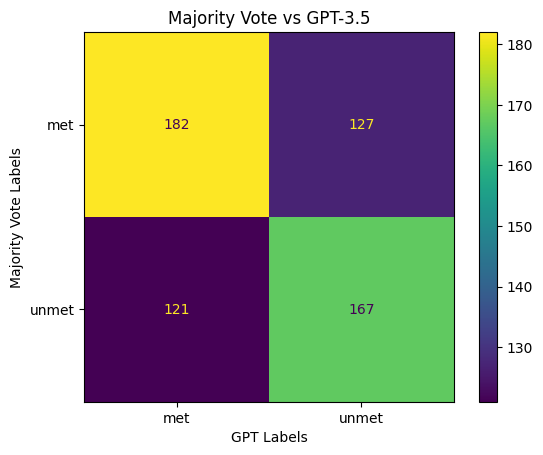

In [16]:
get_majority_scores(clean_gpt3_raters, 'GPT-3.5')

--- Evaluation for Majority Vote ---
Accuracy: 0.5030769230769231
Precision: 0.4823529411764706
Recall: 0.39171974522292996
F1 Score: 0.43233743409490333
Cohen's Kappa: -0.0011444375566258547
              precision    recall  f1-score   support

         met       0.52      0.61      0.56       336
       unmet       0.48      0.39      0.43       314

    accuracy                           0.50       650
   macro avg       0.50      0.50      0.50       650
weighted avg       0.50      0.50      0.50       650




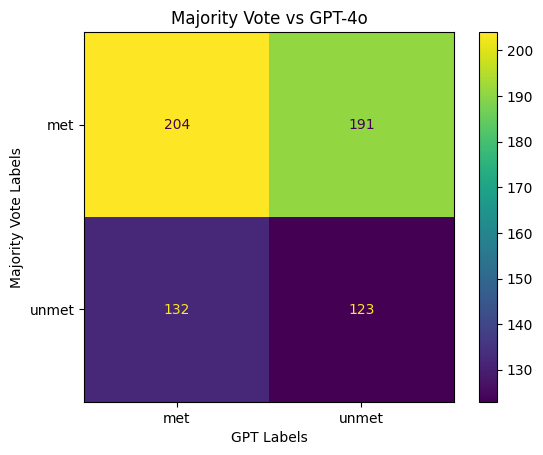

In [17]:
get_majority_scores(clean_gpt4_raters, 'GPT-4o')